# P17AS Progress (All Themes)

This notebook summarizes current/final progress of `run_ablation_12_specify`.
It keeps the original layout-focused view and now adds feature_drop, dense_bias, and rule_router summaries.

In [10]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

ROOT = Path('/workspace/FeaturedMoE')
SUMMARY_PATH = ROOT / 'experiments/run/artifacts/logs/fmoe_n3/ablation_feature_add_v3_a12_kuairec_v1_specify/KuaiRecLargeStrictPosV2_0.2/summary.csv'
OUT_DIR = ROOT / 'experiments/run/fmoe_n3/ablation/docs_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH

PosixPath('/workspace/FeaturedMoE/experiments/run/artifacts/logs/fmoe_n3/ablation_feature_add_v3_a12_kuairec_v1_specify/KuaiRecLargeStrictPosV2_0.2/summary.csv')

In [11]:
summary = pd.read_csv(SUMMARY_PATH)

status_col = next((c for c in ['run_status', 'status', 'state'] if c in summary.columns), None)
if status_col is None:
    raise KeyError(f'No status column found in summary. cols={list(summary.columns)}')

summary = summary[summary[status_col].astype(str).str.lower().eq('run_complete')].copy()
result_path_col = next((c for c in ['result_path', 'best_result_path', 'run_result_path'] if c in summary.columns), None)
if result_path_col is None:
    raise KeyError(f'No result path column found in summary. cols={list(summary.columns)}')

summary['setting_id_num'] = summary['setting_id'].astype(str).str.extract(r'(\d+)').astype(float)
summary = summary.sort_values(['setting_id_num', 'seed_id'])

summary[['run_phase', 'setting_key', 'setting_group', 'seed_id', result_path_col]].head(20)

,run_phase,setting_key,setting_group,seed_id,result_path
9,P17AS_01_S1,ABLS-01_BASELINE_A12,baseline,1,/workspace/jy1559/FMoE/experiments/run/artifac...
8,P17AS_01_S2,ABLS-01_BASELINE_A12,baseline,2,/workspace/jy1559/FMoE/experiments/run/artifac...
7,P17AS_01_S3,ABLS-01_BASELINE_A12,baseline,3,/workspace/jy1559/FMoE/experiments/run/artifac...
6,P17AS_02_S1,ABLS-02_LAYOUT_NO_MACRO_DENSE,layout,1,/workspace/jy1559/FMoE/experiments/run/artifac...
5,P17AS_02_S2,ABLS-02_LAYOUT_NO_MACRO_DENSE,layout,2,/workspace/jy1559/FMoE/experiments/run/artifac...
4,P17AS_02_S3,ABLS-02_LAYOUT_NO_MACRO_DENSE,layout,3,/workspace/jy1559/FMoE/experiments/run/artifac...
12,P17AS_03_S1,ABLS-03_LAYOUT_NO_MACRO_SKIP,layout,1,/workspace/jy1559/FMoE/experiments/run/artifac...
13,P17AS_03_S2,ABLS-03_LAYOUT_NO_MACRO_SKIP,layout,2,/workspace/jy1559/FMoE/experiments/run/artifac...
10,P17AS_03_S3,ABLS-03_LAYOUT_NO_MACRO_SKIP,layout,3,/workspace/jy1559/FMoE/experiments/run/artifac...
11,P17AS_04_S1,ABLS-04_LAYOUT_NO_MID_DENSE,layout,1,/workspace/jy1559/FMoE/experiments/run/artifac...


In [12]:
def _norm_key(s: str) -> str:
    return re.sub(r'[^a-z0-9]', '', str(s).lower())

def _to_float(x):
    try:
        return float(x)
    except Exception:
        return None

def _find_metric(obj, alias_norms):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if _norm_key(k) in alias_norms:
                fv = _to_float(v)
                if fv is not None:
                    return fv
        for v in obj.values():
            found = _find_metric(v, alias_norms)
            if found is not None:
                return found
    elif isinstance(obj, list):
        for v in obj:
            found = _find_metric(v, alias_norms)
            if found is not None:
                return found
    return None

NDCG20_ALIASES = {_norm_key(x) for x in ['ndcg20', 'ndcg@20', 'ndcg_20']}
HR20_ALIASES = {_norm_key(x) for x in ['hr20', 'hr@20', 'hit20', 'hit@20', 'hitrate20', 'hitratio20']}

def load_metrics(result_path):
    p = Path(str(result_path))
    if not p.exists():
        return {'test_ndcg20': None, 'test_hr20': None}
    data = json.loads(p.read_text(encoding='utf-8'))
    test_blob = data.get('test_result') or data.get('test_metrics') or data.get('test') or {}
    nd = _find_metric(test_blob, NDCG20_ALIASES)
    hr = _find_metric(test_blob, HR20_ALIASES)
    if nd is None:
        nd = _find_metric(data, NDCG20_ALIASES)
    if hr is None:
        hr = _find_metric(data, HR20_ALIASES)
    return {'test_ndcg20': nd, 'test_hr20': hr}

rows = []
for _, r in summary.iterrows():
    m = load_metrics(r[result_path_col])
    rows.append({
        'setting_id': r.get('setting_id'),
        'setting_key': r.get('setting_key'),
        'setting_group': r.get('setting_group'),
        'setting_detail': r.get('setting_detail'),
        'seed_id': r.get('seed_id'),
        'test_ndcg20': m['test_ndcg20'],
        'test_hr20': m['test_hr20'],
        'test_mrr20': r.get('test_mrr20'),
        'result_path': r.get(result_path_col),
    })

df = pd.DataFrame(rows)
df['setting_id_num'] = df['setting_id'].astype(str).str.extract(r'(\d+)').astype(float)
df = df.sort_values(['setting_id_num', 'seed_id']).reset_index(drop=True)

df.head(20)

,setting_id,setting_key,setting_group,setting_detail,seed_id,test_ndcg20,test_hr20,test_mrr20,result_path,setting_id_num
0,1,ABLS-01_BASELINE_A12,baseline,A12 fixed baseline selected by valid+0.5*test ...,1,0.1727,0.1833,0.1698,/workspace/jy1559/FMoE/experiments/run/artifac...,1.0
1,1,ABLS-01_BASELINE_A12,baseline,A12 fixed baseline selected by valid+0.5*test ...,2,0.1736,0.1847,0.1705,/workspace/jy1559/FMoE/experiments/run/artifac...,1.0
2,1,ABLS-01_BASELINE_A12,baseline,A12 fixed baseline selected by valid+0.5*test ...,3,0.1735,0.1849,0.1703,/workspace/jy1559/FMoE/experiments/run/artifac...,1.0
3,2,ABLS-02_LAYOUT_NO_MACRO_DENSE,layout,Replace macro_ffn with dense_plain,1,0.1717,0.1825,0.1687,/workspace/jy1559/FMoE/experiments/run/artifac...,2.0
4,2,ABLS-02_LAYOUT_NO_MACRO_DENSE,layout,Replace macro_ffn with dense_plain,2,0.1715,0.1828,0.1685,/workspace/jy1559/FMoE/experiments/run/artifac...,2.0
5,2,ABLS-02_LAYOUT_NO_MACRO_DENSE,layout,Replace macro_ffn with dense_plain,3,0.1717,0.1825,0.1687,/workspace/jy1559/FMoE/experiments/run/artifac...,2.0
6,3,ABLS-03_LAYOUT_NO_MACRO_SKIP,layout,Remove macro_ffn without dense replacement,1,0.1718,0.1833,0.1687,/workspace/jy1559/FMoE/experiments/run/artifac...,3.0
7,3,ABLS-03_LAYOUT_NO_MACRO_SKIP,layout,Remove macro_ffn without dense replacement,2,0.1720,0.1830,0.1689,/workspace/jy1559/FMoE/experiments/run/artifac...,3.0
8,3,ABLS-03_LAYOUT_NO_MACRO_SKIP,layout,Remove macro_ffn without dense replacement,3,0.1722,0.1844,0.1690,/workspace/jy1559/FMoE/experiments/run/artifac...,3.0
9,4,ABLS-04_LAYOUT_NO_MID_DENSE,layout,Replace mid_ffn with dense_plain,1,0.1707,0.1800,0.1681,/workspace/jy1559/FMoE/experiments/run/artifac...,4.0


## All-Themes Progress (Completed Only)

This table and figure include completed settings across `layout`, `feature_drop`, `dense_bias`, and `rule_router`, with baseline included in each panel.

In [13]:
layout_df = df[df['setting_group'].eq('layout')].copy()

# Keep only settings where all requested seeds are complete (expected 3 by default).
expected_seeds = sorted(set(pd.to_numeric(summary['seed_id'], errors='coerce').dropna().astype(int).tolist()))
expected_seed_count = len(expected_seeds) if expected_seeds else 3

seed_counts = layout_df.groupby('setting_key')['seed_id'].nunique().rename('n_seeds').reset_index()
layout_df = layout_df.merge(seed_counts, on='setting_key', how='left')
completed_layout_df = layout_df[layout_df['n_seeds'] >= expected_seed_count].copy()

layout_agg = (
    completed_layout_df
    .groupby(['setting_id', 'setting_key', 'setting_detail'], as_index=False)
    .agg(
        n_seeds=('seed_id', 'nunique'),
        test_ndcg20_mean=('test_ndcg20', 'mean'),
        test_ndcg20_std=('test_ndcg20', 'std'),
        test_hr20_mean=('test_hr20', 'mean'),
        test_hr20_std=('test_hr20', 'std'),
        test_mrr20_mean=('test_mrr20', 'mean'),
    )
)
layout_agg['setting_id_num'] = layout_agg['setting_id'].astype(str).str.extract(r'(\d+)').astype(float)
layout_agg = layout_agg.sort_values('setting_id_num').reset_index(drop=True)

layout_agg

,setting_id,setting_key,setting_detail,n_seeds,test_ndcg20_mean,test_ndcg20_std,test_hr20_mean,test_hr20_std,test_mrr20_mean,setting_id_num
0,2,ABLS-02_LAYOUT_NO_MACRO_DENSE,Replace macro_ffn with dense_plain,3,0.171633,0.000115,0.182600,0.000173,0.168633,2.0
1,3,ABLS-03_LAYOUT_NO_MACRO_SKIP,Remove macro_ffn without dense replacement,3,0.172000,0.000200,0.183567,0.000737,0.168867,3.0
2,4,ABLS-04_LAYOUT_NO_MID_DENSE,Replace mid_ffn with dense_plain,3,0.170933,0.000252,0.181133,0.001266,0.168133,4.0
3,5,ABLS-05_LAYOUT_NO_MID_SKIP,Remove mid_ffn without dense replacement,3,0.172833,0.000208,0.184767,0.000404,0.169667,5.0
4,6,ABLS-06_LAYOUT_NO_MICRO_DENSE,Replace micro_ffn with dense_plain,3,0.170967,0.000473,0.181567,0.000850,0.168100,6.0
5,7,ABLS-07_LAYOUT_NO_MICRO_SKIP,Remove micro_ffn without dense replacement,3,0.172033,0.000839,0.181867,0.001940,0.169333,7.0
6,8,ABLS-08_LAYOUT_ATTN_BEFORE_MID,Insert attention block before mid_ffn,3,0.171300,0.000500,0.181667,0.002113,0.168500,8.0
7,9,ABLS-09_LAYOUT_NO_ATTN_ONLY_MOEFFN,Drop attention blocks and keep only MoE FFN bl...,3,0.172033,0.000493,0.181233,0.000416,0.169533,9.0
8,10,ABLS-10_LAYOUT_DENSE_FULL_ONLY,"All MoE removed, dense FFN only (macro/mid/micro)",3,0.162467,0.001531,0.172667,0.003349,0.159500,10.0
9,11,ABLS-11_LAYOUT_DENSE_MACRO_MID_ONLY,Dense macro/mid only (drop micro stage),3,0.163967,0.000153,0.173033,0.000808,0.161400,11.0


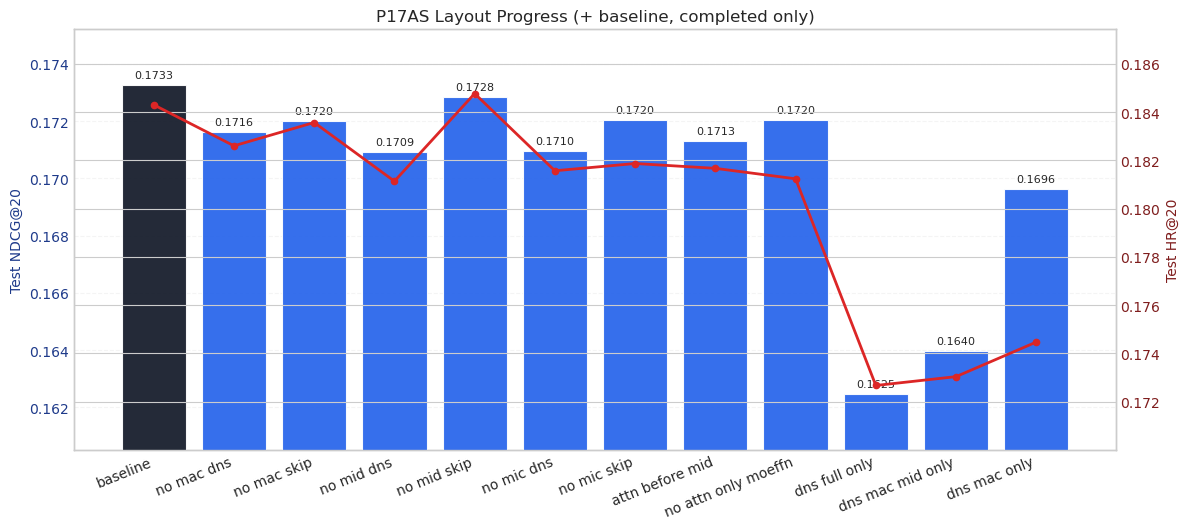

In [14]:
if layout_agg.empty:
    print('No fully completed layout settings yet.')
else:
    # Add baseline aggregate as the left-most reference.
    baseline_df = df[df['setting_group'].eq('baseline')].copy()
    baseline_agg = (
        baseline_df
        .groupby(['setting_id', 'setting_key', 'setting_detail'], as_index=False)
        .agg(
            n_seeds=('seed_id', 'nunique'),
            test_ndcg20_mean=('test_ndcg20', 'mean'),
            test_ndcg20_std=('test_ndcg20', 'std'),
            test_hr20_mean=('test_hr20', 'mean'),
            test_hr20_std=('test_hr20', 'std'),
            test_mrr20_mean=('test_mrr20', 'mean'),
        )
)
    baseline_agg['setting_id_num'] = baseline_agg['setting_id'].astype(str).str.extract(r'(\d+)').astype(float)

    plot_df = pd.concat([baseline_agg, layout_agg], ignore_index=True)
    plot_df = plot_df.drop_duplicates(subset=['setting_key'], keep='first').copy()
    plot_df = plot_df.sort_values(['setting_id_num']).reset_index(drop=True)

    def _short_label(k: str) -> str:
        s = str(k)
        if 'BASELINE' in s.upper():
            return 'baseline'
        s = re.sub(r'^ABLS-\d+_', '', s)
        s = s.lower()
        s = s.replace('layout_', '')
        s = s.replace('dense', 'dns')
        s = s.replace('macro', 'mac').replace('micro', 'mic')
        s = s.replace('_', ' ')
        return s

    plot_df['x_label'] = plot_df['setting_key'].map(_short_label)

    fig, ax1 = plt.subplots(figsize=(12, 5.4))
    x = np.arange(len(plot_df))

    colors = ['#111827'] + ['#2563EB'] * (len(plot_df) - 1)
    bars = ax1.bar(
        x,
        plot_df['test_ndcg20_mean'],
        color=colors,
        alpha=0.92,
        edgecolor='white',
        linewidth=0.8,
        zorder=3,
        label='Mean Test NDCG@20',
    )

    # Keep horizontal grid behind bars for a cleaner look.
    ax1.set_axisbelow(True)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.2, zorder=0)
    ax1.xaxis.grid(False)

    nd = pd.to_numeric(plot_df['test_ndcg20_mean'], errors='coerce').dropna()
    hr = pd.to_numeric(plot_df['test_hr20_mean'], errors='coerce').dropna()
    if not nd.empty:
        nd_pad = max((nd.max() - nd.min()) * 0.18, 0.0015)
        ax1.set_ylim(max(0.0, nd.min() - nd_pad), min(1.0, nd.max() + nd_pad))
    ax1.set_ylabel('Test NDCG@20', color='#1E3A8A')
    ax1.tick_params(axis='y', labelcolor='#1E3A8A')

    y_span = ax1.get_ylim()[1] - ax1.get_ylim()[0]
    for i, v in enumerate(plot_df['test_ndcg20_mean']):
        if pd.notna(v):
            ax1.text(i, float(v) + y_span * 0.012, f'{float(v):.4f}', ha='center', va='bottom', fontsize=8)

    ax2 = ax1.twinx()
    ax2.plot(
        x,
        plot_df['test_hr20_mean'],
        color='#DC2626',
        marker='o',
        linewidth=2,
        markersize=4.5,
        zorder=4,
        label='Mean Test HR@20',
    )
    if not hr.empty:
        hr_pad = max((hr.max() - hr.min()) * 0.22, 0.002)
        ax2.set_ylim(max(0.0, hr.min() - hr_pad), min(1.0, hr.max() + hr_pad))
    ax2.set_ylabel('Test HR@20', color='#7F1D1D')
    ax2.tick_params(axis='y', labelcolor='#7F1D1D')

    ax1.set_xticks(x)
    ax1.set_xticklabels(plot_df['x_label'], rotation=22, ha='right')
    ax1.set_title('P17AS Layout Progress (+ baseline, completed only)')

    fig.tight_layout()
    out_path = OUT_DIR / 'p17as_layout_progress_completed_only.png'
    fig.savefig(out_path, dpi=220, bbox_inches='tight')
    plt.show()
    out_path

## All Themes Summary (Completed Runs)

This section adds completed results for `feature_drop`, `dense_bias`, and `rule_router`
along with a compact all-theme comparison figure (baseline included per panel).

,setting_group,setting_id,setting_key,n_seeds,test_ndcg20_mean,test_hr20_mean,test_mrr20_mean
0,baseline,1,ABLS-01_BASELINE_A12,3,0.173267,0.184300,0.170200
1,dense_bias,22,ABLS-22_DENSE_GATED_BIAS_MACRO_MID,3,0.168433,0.174600,0.166733
2,dense_bias,23,ABLS-23_DENSE_GATED_BIAS_FULL,3,0.166933,0.176833,0.164233
3,dense_bias,24,ABLS-24_DENSE_GROUP_GATED_MACRO_MID,3,0.163867,0.172833,0.161333
4,dense_bias,25,ABLS-25_DENSE_GROUP_GATED_FULL,3,0.161200,0.169300,0.158833
5,dense_bias,26,ABLS-26_DENSE_NO_INJECTION_FULL,3,0.160600,0.168833,0.158233
6,dense_bias,27,ABLS-27_DENSE_NO_INJECTION_MACRO_MID,3,0.163767,0.172400,0.161333
7,dense_bias,28,ABLS-28_DENSE_MACRO_ONLY_GATED,3,0.170900,0.175900,0.169500
8,dense_bias,29,ABLS-29_DENSE_MID_ONLY_GATED,3,0.170533,0.176000,0.169033
9,feature_drop,13,ABLS-13_FEATURE_DROP_CATEGORY,3,0.171700,0.182933,0.168700


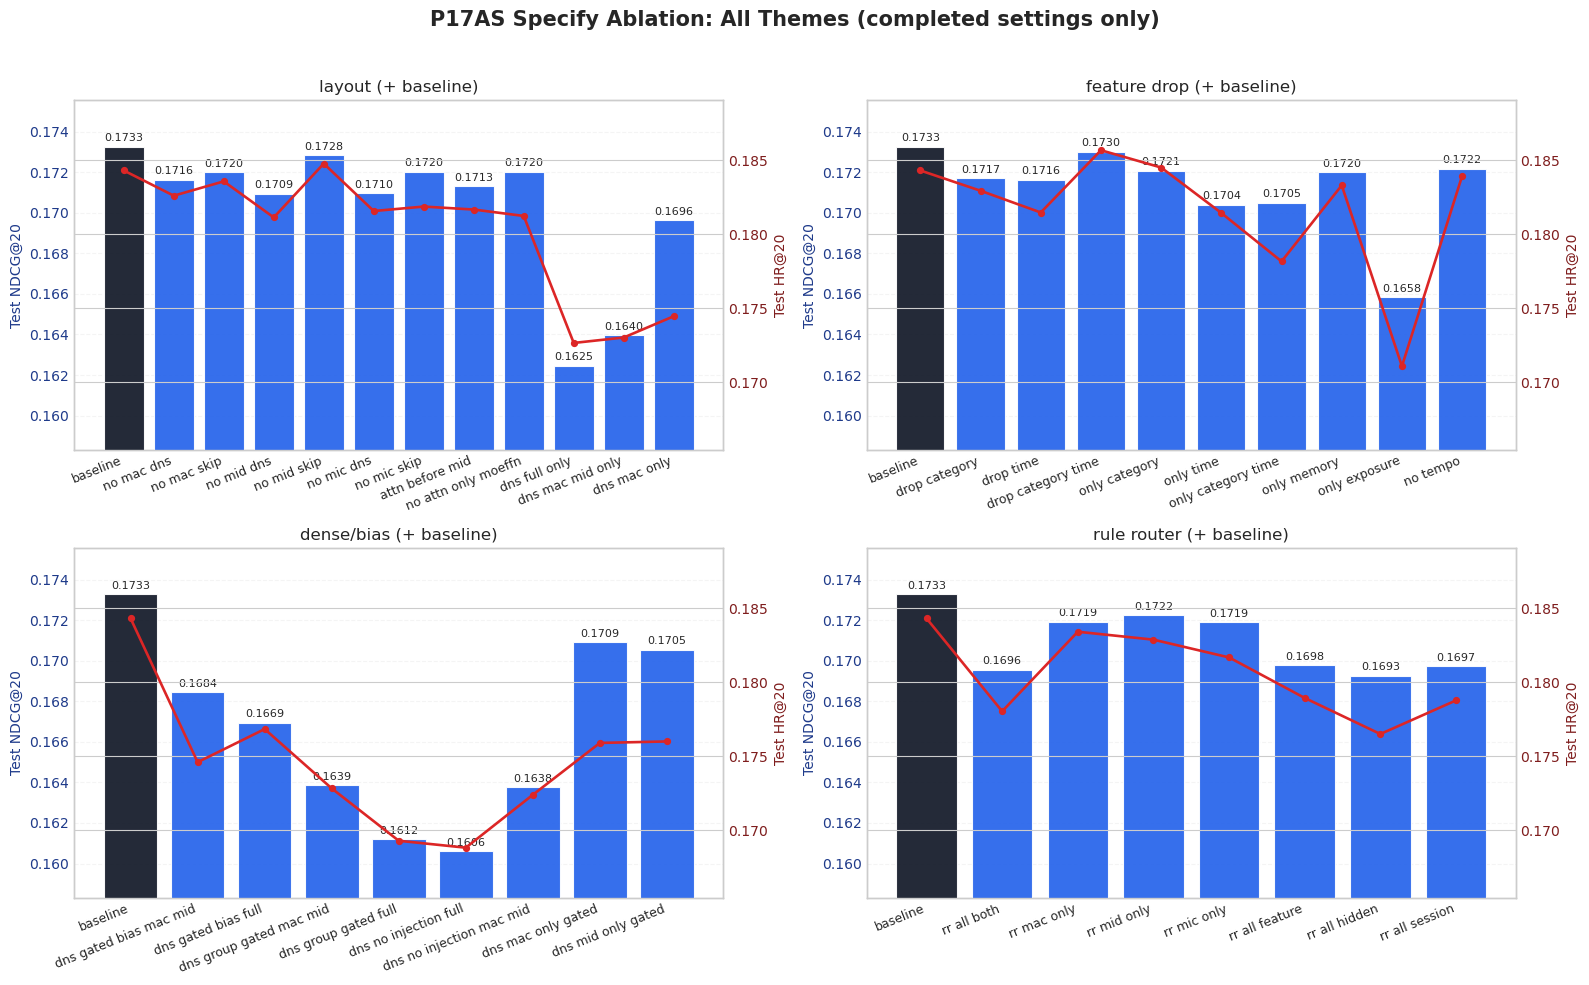

PosixPath('/workspace/FeaturedMoE/experiments/run/fmoe_n3/ablation/docs_results/p17as_all_themes_completed.png')

In [15]:
# Reload summary/results from disk to avoid stale in-memory snapshots when re-running only this cell.
summary_now = pd.read_csv(SUMMARY_PATH)

status_col_now = next((c for c in ['run_status', 'status', 'state'] if c in summary_now.columns), None)
if status_col_now is None:
    raise KeyError(f'No status column found in summary. cols={list(summary_now.columns)}')

result_path_col_now = next((c for c in ['result_path', 'best_result_path', 'run_result_path'] if c in summary_now.columns), None)
if result_path_col_now is None:
    raise KeyError(f'No result path column found in summary. cols={list(summary_now.columns)}')

summary_now = summary_now[summary_now[status_col_now].astype(str).str.lower().eq('run_complete')].copy()

rows = []
for _, r in summary_now.iterrows():
    m = load_metrics(r[result_path_col_now])
    rows.append({
        'setting_id': r.get('setting_id'),
        'setting_key': r.get('setting_key'),
        'setting_group': r.get('setting_group'),
        'setting_detail': r.get('setting_detail'),
        'seed_id': r.get('seed_id'),
        'test_ndcg20': m['test_ndcg20'],
        'test_hr20': m['test_hr20'],
        'test_mrr20': r.get('test_mrr20'),
        'result_path': r.get(result_path_col_now),
    })

df_now = pd.DataFrame(rows)
df_now['setting_id_num'] = df_now['setting_id'].astype(str).str.extract(r'(\d+)').astype(float)
df_now['seed_id'] = pd.to_numeric(df_now['seed_id'], errors='coerce').astype('Int64')
df_now = df_now.sort_values(['setting_id_num', 'seed_id']).reset_index(drop=True)

# Aggregate completed settings by theme (requiring full seed coverage per setting).
expected_seeds = sorted(df_now['seed_id'].dropna().astype(int).unique().tolist())
expected_seed_count = len(expected_seeds) if expected_seeds else 3

theme_order = ['layout', 'feature_drop', 'dense_bias', 'rule_router']
core_df = df_now[df_now['setting_group'].isin(theme_order + ['baseline'])].copy()

seed_counts = core_df.groupby('setting_key')['seed_id'].nunique().rename('n_seeds').reset_index()
core_df = core_df.merge(seed_counts, on='setting_key', how='left')
core_df = core_df[core_df['n_seeds'] >= expected_seed_count].copy()

agg_all = (
    core_df
    .groupby(['setting_group', 'setting_id', 'setting_key', 'setting_detail'], as_index=False)
    .agg(
        n_seeds=('seed_id', 'nunique'),
        test_ndcg20_mean=('test_ndcg20', 'mean'),
        test_ndcg20_std=('test_ndcg20', 'std'),
        test_hr20_mean=('test_hr20', 'mean'),
        test_hr20_std=('test_hr20', 'std'),
        test_mrr20_mean=('test_mrr20', 'mean'),
    )
)
agg_all['setting_id_num'] = agg_all['setting_id'].astype(str).str.extract(r'(\d+)').astype(float)
agg_all = agg_all.sort_values(['setting_group', 'setting_id_num']).reset_index(drop=True)

display(agg_all[['setting_group', 'setting_id', 'setting_key', 'n_seeds', 'test_ndcg20_mean', 'test_hr20_mean', 'test_mrr20_mean']])

baseline_row = agg_all[agg_all['setting_group'].eq('baseline')].copy()
if baseline_row.empty:
    print('Baseline aggregate not found. Plot will omit baseline reference.')
    baseline_row = pd.DataFrame(columns=agg_all.columns)
else:
    baseline_row = baseline_row.sort_values('setting_id_num').head(1).copy()

def _short_label(k: str) -> str:
    s = str(k)
    if 'BASELINE' in s.upper():
        return 'baseline'
    s = re.sub(r'^ABLS-\d+_', '', s).lower()
    s = s.replace('layout_', '').replace('feature_', '').replace('rule_router_', 'rr_')
    s = s.replace('dense', 'dns').replace('macro', 'mac').replace('micro', 'mic')
    s = s.replace('timestamp', 'time')
    s = s.replace('_', ' ')
    s = re.sub(r'\s+', ' ', s).strip()
    return s

panel_data = {}
for theme in theme_order:
    d = agg_all[agg_all['setting_group'].eq(theme)].copy().sort_values('setting_id_num')
    if not baseline_row.empty:
        d = pd.concat([baseline_row, d], ignore_index=True)
        d = d.drop_duplicates(subset=['setting_key'], keep='first')
    d['x_label'] = d['setting_key'].map(_short_label)
    panel_data[theme] = d

# Global limits for cross-panel comparability.
nd_all = pd.concat([panel_data[t]['test_ndcg20_mean'] for t in theme_order if not panel_data[t].empty], axis=0)
hr_all = pd.concat([panel_data[t]['test_hr20_mean'] for t in theme_order if not panel_data[t].empty], axis=0)

def _ylim_with_margin(series, margin_ratio=0.16, min_pad=0.001):
    s = pd.to_numeric(series, errors='coerce').dropna()
    if s.empty:
        return (0.0, 1.0)
    mn, mx = float(s.min()), float(s.max())
    pad = max((mx - mn) * margin_ratio, min_pad)
    lo = max(0.0, mn - pad)
    hi = min(1.0, mx + pad)
    if np.isclose(lo, hi):
        hi = min(1.0, lo + 0.01)
    return (lo, hi)

nd_ylim = _ylim_with_margin(nd_all, margin_ratio=0.18, min_pad=0.0015)
hr_ylim = _ylim_with_margin(hr_all, margin_ratio=0.2, min_pad=0.002)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
title_map = {
    'layout': 'layout',
    'feature_drop': 'feature drop',
    'dense_bias': 'dense/bias',
    'rule_router': 'rule router',
}

for i, theme in enumerate(theme_order):
    ax1 = axes[i]
    d = panel_data[theme].copy().reset_index(drop=True)
    if d.empty:
        ax1.axis('off')
        continue

    x = np.arange(len(d))
    colors = ['#111827' if j == 0 else '#2563EB' for j in range(len(d))]
    bars = ax1.bar(
        x, d['test_ndcg20_mean'].astype(float),
        color=colors, alpha=0.92, edgecolor='white', linewidth=0.8, zorder=3
    )

    ax1.set_axisbelow(True)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.2, zorder=0)
    ax1.xaxis.grid(False)

    ax1.set_ylim(*nd_ylim)
    ax1.set_ylabel('Test NDCG@20', color='#1E3A8A')
    ax1.tick_params(axis='y', labelcolor='#1E3A8A')

    y_span = nd_ylim[1] - nd_ylim[0]
    for j, v in enumerate(d['test_ndcg20_mean']):
        if pd.notna(v):
            ax1.text(j, float(v) + y_span * 0.01, f'{float(v):.4f}', ha='center', va='bottom', fontsize=8)

    ax2 = ax1.twinx()
    ax2.plot(x, d['test_hr20_mean'].astype(float), color='#DC2626', marker='o', linewidth=1.9, markersize=4.2, zorder=4)
    ax2.set_ylim(*hr_ylim)
    ax2.set_ylabel('Test HR@20', color='#7F1D1D')
    ax2.tick_params(axis='y', labelcolor='#7F1D1D')

    ax1.set_xticks(x)
    ax1.set_xticklabels(d['x_label'], rotation=22, ha='right', fontsize=9)
    ax1.set_title(f"{title_map.get(theme, theme)} (+ baseline)")

fig.suptitle('P17AS Specify Ablation: All Themes (completed settings only)', fontsize=15, fontweight='bold', y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])

out_all = OUT_DIR / 'p17as_all_themes_completed.png'
fig.savefig(out_all, dpi=230, bbox_inches='tight')
plt.show()
out_all